# 1. Аудит одномерного исследовательского ряда

**Цели:** проверить схему, пропуски, масштаб и визуально отделить центр распределения от редких событий. Данные фиксированы; истинных меток экстремумов нет.

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data/generated/additive_fractal_series.csv").exists())
DATA = ROOT / "data/generated/additive_fractal_series.csv"
SEED = 42
rng = np.random.default_rng(SEED)
df = pd.read_csv(DATA)
x = df["value"].to_numpy()
assert np.isfinite(x).all() and x.ndim == 1

summary = df.describe(percentiles=[.01,.05,.5,.95,.99]).T
summary

,count,mean,std,min,1%,5%,50%,95%,99%,max
timestamp,1500.0,749.500000,433.157015,0.000000,14.990000,74.950000,749.500000,1424.050000,1484.010000,1499.000000
value,1500.0,0.002450,1.125550,-11.942419,-3.042635,-1.486326,0.071601,1.472530,2.112200,4.668888
oscillators,1500.0,0.013898,0.851011,-1.880617,-1.810593,-1.428279,0.025085,1.364154,1.793514,1.887859
extreme_injection,1500.0,-0.005277,0.646574,-10.146038,-2.052984,0.000000,0.000000,0.004060,1.597127,6.739934
simple_noise,1500.0,-0.006171,0.299927,-1.094524,-0.718325,-0.505692,0.001036,0.485110,0.689907,0.953656
is_extreme,1500.0,0.100000,0.300100,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000


,count,mean,std,min,1%,5%,50%,95%,99%,max
timestamp,1500.0,749.500000,433.157015,0.000000,14.990000,74.950000,749.500000,1424.050000,1484.010000,1499.000000
value,1500.0,0.002450,1.125550,-11.942419,-3.042635,-1.486326,0.071601,1.472530,2.112200,4.668888
oscillators,1500.0,0.013898,0.851011,-1.880617,-1.810593,-1.428279,0.025085,1.364154,1.793514,1.887859
extreme_injection,1500.0,-0.005277,0.646574,-10.146038,-2.052984,0.000000,0.000000,0.004060,1.597127,6.739934
simple_noise,1500.0,-0.006171,0.299927,-1.094524,-0.718325,-0.505692,0.001036,0.485110,0.689907,0.953656
is_extreme,1500.0,0.100000,0.300100,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000


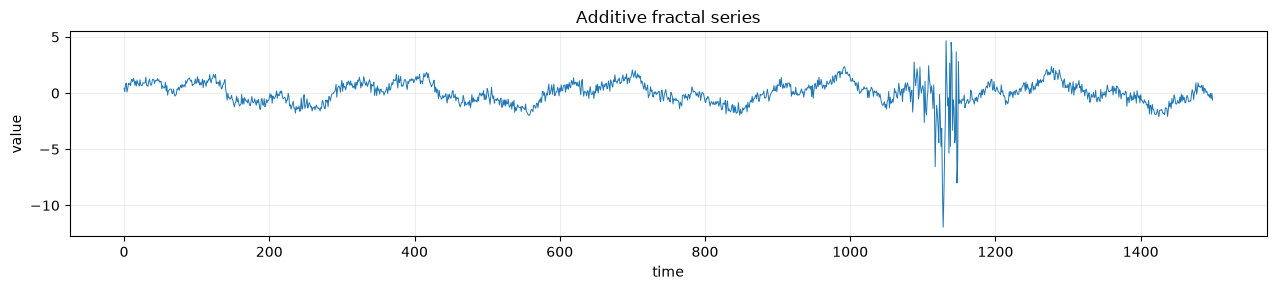

In [2]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(df.timestamp, x, lw=.7)
ax.set(title="Additive fractal series", xlabel="time", ylabel="value")
ax.grid(alpha=.2); fig.tight_layout()
summary

## Как устроен этот ряд: аддитивная декомпозиция генератора

Выше ряд разобран как есть, без знания о том, откуда он взялся — обычный аудит неразмеченных данных. Здесь, для разнообразия, используется provenance: `additive_fractal_series.csv` явно хранит все три слагаемых как отдельные колонки, а не только их сумму — `value = oscillators + extreme_injection + simple_noise` (см. `evt_demo.data_generator.generate_additive_fractal_series` и `scripts/generate_datasets.py`). Ничего не нужно регенерировать: ниже — просто три уже загруженные колонки, плюс числовая проверка, что их сумма действительно совпадает с `value`.

In [3]:
oscillators = df["oscillators"].to_numpy()
extreme_injection = df["extreme_injection"].to_numpy()
simple_noise = df["simple_noise"].to_numpy()
event_mask = df["is_extreme"].to_numpy(dtype=bool)

# Not illustrative only: confirm the three stored columns actually sum to `value`.
resum = np.allclose(oscillators + extreme_injection + simple_noise, x)
{"oscillators_plus_extreme_plus_noise_equals_value": resum,
 "extreme_injection_max_abs": float(np.abs(extreme_injection).max()),
 "simple_noise_std": float(simple_noise.std())}

{'oscillators_plus_extreme_plus_noise_equals_value': True,
 'extreme_injection_max_abs': 10.146038361461548,
 'simple_noise_std': 0.29982677812545183}

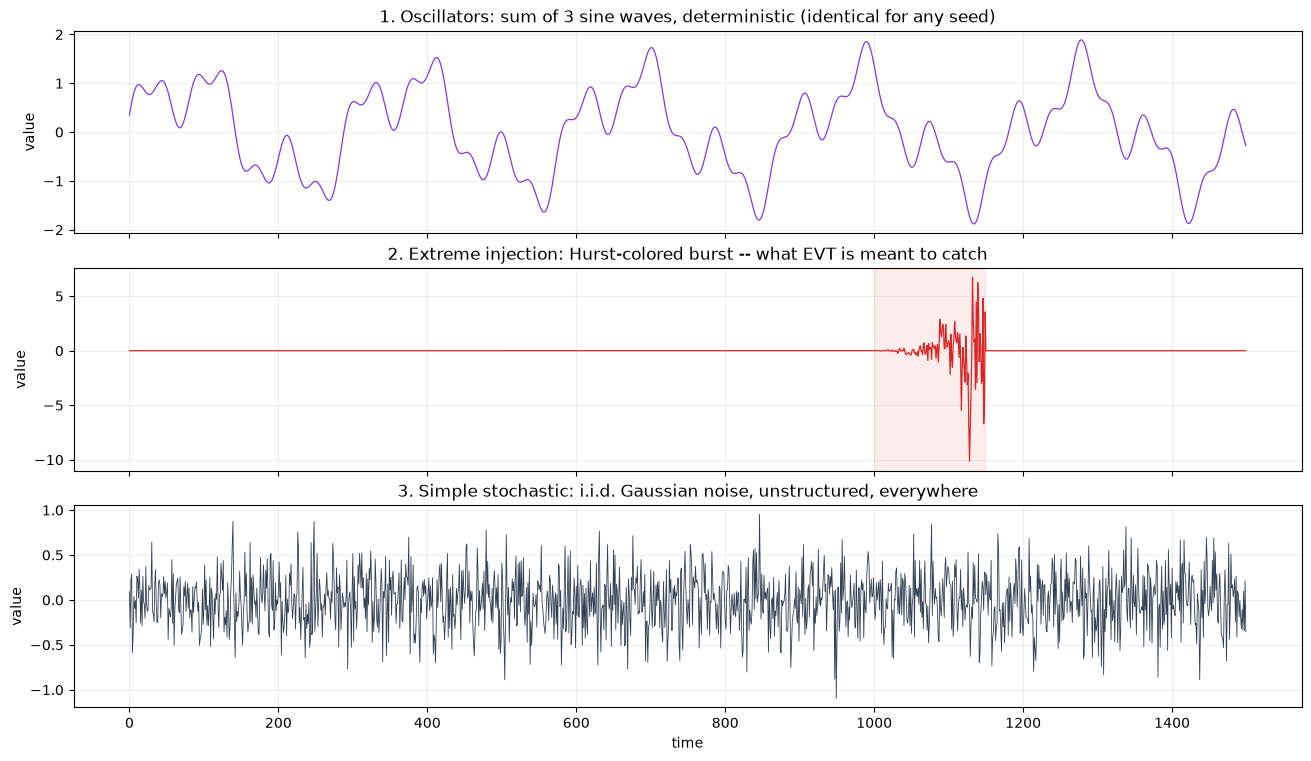

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(13, 7.5), sharex=True, constrained_layout=True)

axes[0].plot(df["timestamp"], oscillators, color="#7c3aed", linewidth=0.9)
axes[0].set(title="1. Oscillators: sum of 3 sine waves, deterministic (identical for any seed)", ylabel="value")

axes[1].plot(df["timestamp"], extreme_injection, color="#dc2626", linewidth=0.9)
axes[1].axvspan(df.loc[event_mask, "timestamp"].iloc[0], df.loc[event_mask, "timestamp"].iloc[-1],
                color="#dc2626", alpha=0.08)
axes[1].set(title="2. Extreme injection: Hurst-colored burst -- what EVT is meant to catch", ylabel="value")

axes[2].plot(df["timestamp"], simple_noise, color="#334155", linewidth=0.6)
axes[2].set(title="3. Simple stochastic: i.i.d. Gaussian noise, unstructured, everywhere",
           xlabel="time", ylabel="value")

for ax in axes:
    ax.grid(alpha=.2)
plt.show()

Панель 1 — чистая функция времени: та же сумма трёх синусоид получилась бы при любом `seed`, случайность в ней отсутствует. Панель 2 — Hurst/DFA-окрашенный шумовой всплеск, а не гладкий импульс: это единственное слагаемое, которое отлично от нуля лишь на размеченном окне события, и именно на него рассчитан POT/GPD-детектор EVT (ноутбук 3). Панель 3 — простой гауссовский шум без временной окраски, присутствующий на всём ряде независимо от события. Сложение всех трёх (проверено выше через `np.allclose`, не только нарисовано) — это в точности колонка `value`, уже загруженная в начале ноутбука.

**Самопроверка:** почему панель 1 периодична, а панель 2 — нет? Почему у панели 2 форма шумовая, а не гладкая, в отличие от прежнего генератора `generate_fractal_extreme_series` (сглаженный `sin²`-импульс)? Что случится с детектируемостью события, если `simple_noise_sigma` заметно увеличить — на какой панели это будет видно в первую очередь?

Наблюдаемые пики — кандидаты, а не размеченная истина. Не выбирайте порог только по этой картинке.

**Самопроверка:** почему отсутствие пропусков не гарантирует качество? Что изменит стандартизация? Почему нельзя считать каждый высокий отсчёт независимым событием?